In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive/cosesmic/layers/landslide_points_with_lsi.csv

In [ ]:
df1 = pd.read_csv("/content/drive/MyDrive/cosesmic/layers/landslide_points_with_lsi.csv",encoding='latin',low_memory=False)
df2 = pd.read_csv("/content/drive/MyDrive/cosesmic/layers/non_landslide_points_with_lsi_500.csv",encoding='latin',low_memory=False)

In [ ]:
df2.head()

,fid,id,LSI_1,label
0,1,0,-29.499140,0
1,2,1,-26.260731,0
2,3,2,-23.627785,0
3,4,3,-27.638666,0
4,5,4,-24.765900,0


In [ ]:

df = pd.concat([df1, df2], ignore_index=True)
df = df.dropna(subset=["LSI_1"])   # remove masked values

In [ ]:
df

,fid,gid,slide_no,latitude,longitude,communicat,persons_de,nh_sh_loca,people_aff,alert,...,twi_class1,aspect_class1,lulc_class1,soil_type1,max_rainfall_class1,mean_monsoon_class1,mean_rainfall_class1,LSI_1,label,id
0,1,19837.0,UK/CHA/53O15/2016/29,29.480917,79.984417,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,30.0,3661.0,2.0,2.0,2.0,-4.934068,1,NaN
1,2,19839.0,UK/ALM/53O15/2016/48,29.481724,79.968877,NaN,NaN,NaN,NaN,NaN,...,2.0,4.0,30.0,3661.0,2.0,2.0,2.0,-1.451165,1,NaN
2,3,19840.0,UK/PIT/62C03/2016/112,29.483224,80.002729,NaN,NaN,NaN,NaN,NaN,...,2.0,8.0,10.0,3661.0,2.0,2.0,2.0,-21.021616,1,NaN
3,4,19842.0,UK/ALM/53O15/2016/37,29.484713,79.972357,NaN,NaN,NaN,NaN,NaN,...,2.0,3.0,30.0,3661.0,2.0,2.0,2.0,-12.572570,1,NaN
4,5,19843.0,UK/CHA/53O15/2016/36,29.484810,79.991369,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,30.0,3661.0,2.0,2.0,2.0,-3.841598,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32033,16015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-14.383375,0,16014.0
32034,16016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-20.211676,0,16015.0
32035,16017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-22.718649,0,16016.0
32036,16018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-37.928123,0,16017.0


In [ ]:
df.to_csv("/content/drive/MyDrive/thesis/validation_points.csv", index=False)

In [ ]:
import pandas as pd
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/thesis/validation_points.csv",low_memory=False)

In [ ]:
y_true = df["label"]
y_score = df["LSI_1"]


In [ ]:
y_true.value_counts()

,count
label,
1,15991
0,13626


In [ ]:
y_true.values

array([1, 1, 1, ..., 0, 0, 0])

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

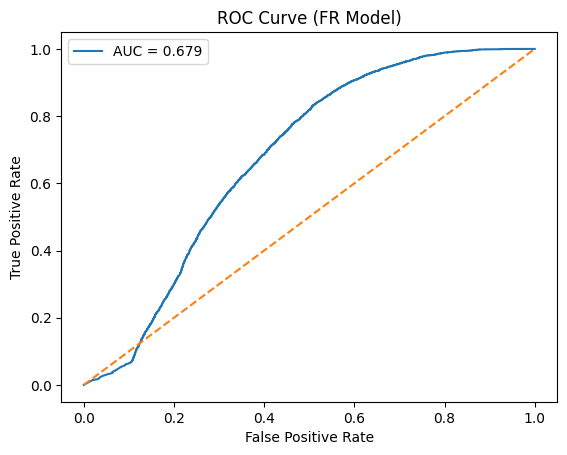

In [ ]:
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (FR Model)")
plt.legend()
plt.show()


In [ ]:
print("AUC:", roc_auc)

AUC: 0.6786284649896133
